# The 10-Armed Testbed

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

### Generating the Testbed

The 'testbed' is the set of probability distributions corresponding to the arms of the bandit, in this case, 

In [3]:
def make_testbed(k=10, n_runs=2000, rng=rng):
    """q*(a) for each of the k arms, for each of n_runs independent bandit problems."""
    return rng.normal(loc=0.0, scale=1.0, size=(n_runs, k))

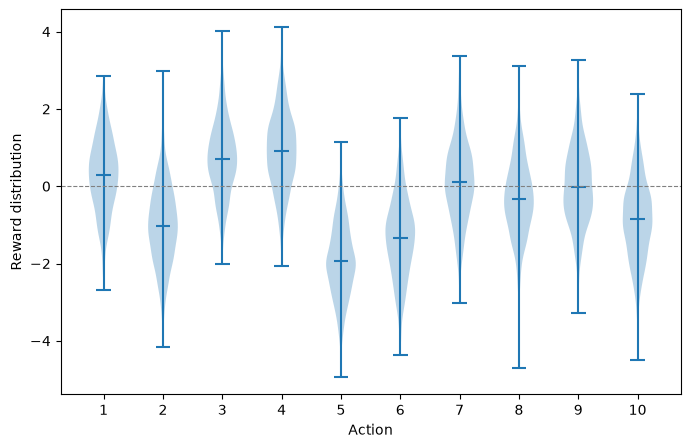

In [4]:
# violin plot of the reward distribution for each arm of a single bandit problem, mirroring Figure 2.1
q_true_sample = make_testbed(k=10, n_runs=1)[0]
samples = rng.normal(loc=q_true_sample, scale=1.0, size=(1000, 10))

fig, ax = plt.subplots(figsize=(8, 5))
ax.violinplot(samples, showmeans=True)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Action")
ax.set_ylabel("Reward distribution")
ax.set_xticks(range(1, 11))
plt.show()

## Epsilon-Greedy Action Selection

In [5]:
def run_epsilon_greedy(q_true, epsilon, n_steps=1000, rng=rng):
    """Run epsilon-greedy action-value learning across all runs in q_true simultaneously.

    q_true: (n_runs, k) array of true action values.
    Returns (avg_reward, pct_optimal_action), each of shape (n_steps,).
    """
    n_runs, k = q_true.shape
    Q = np.zeros((n_runs, k))
    N = np.zeros((n_runs, k))
    optimal_action = np.argmax(q_true, axis=1)
    run_idx = np.arange(n_runs)

    rewards = np.zeros((n_runs, n_steps))
    is_optimal = np.zeros((n_runs, n_steps), dtype=bool)

    for t in range(n_steps):
        explore = rng.random(n_runs) < epsilon
        greedy_actions = np.argmax(Q, axis=1)
        random_actions = rng.integers(0, k, size=n_runs)
        actions = np.where(explore, random_actions, greedy_actions)

        reward = rng.normal(q_true[run_idx, actions], 1.0)

        N[run_idx, actions] += 1
        Q[run_idx, actions] += (reward - Q[run_idx, actions]) / N[run_idx, actions]

        rewards[:, t] = reward
        is_optimal[:, t] = actions == optimal_action

    avg_reward = rewards.mean(axis=0)
    pct_optimal_action = is_optimal.mean(axis=0) * 100
    return avg_reward, pct_optimal_action

## Running the Experiment

In [6]:
k = 10
n_runs = 2000
n_steps = 1000
epsilons = [0.0, 0.01, 0.1]

q_true = make_testbed(k=k, n_runs=n_runs, rng=rng)

results = {
    epsilon: run_epsilon_greedy(q_true, epsilon, n_steps=n_steps, rng=rng)
    for epsilon in epsilons
}

## Results: Average Reward

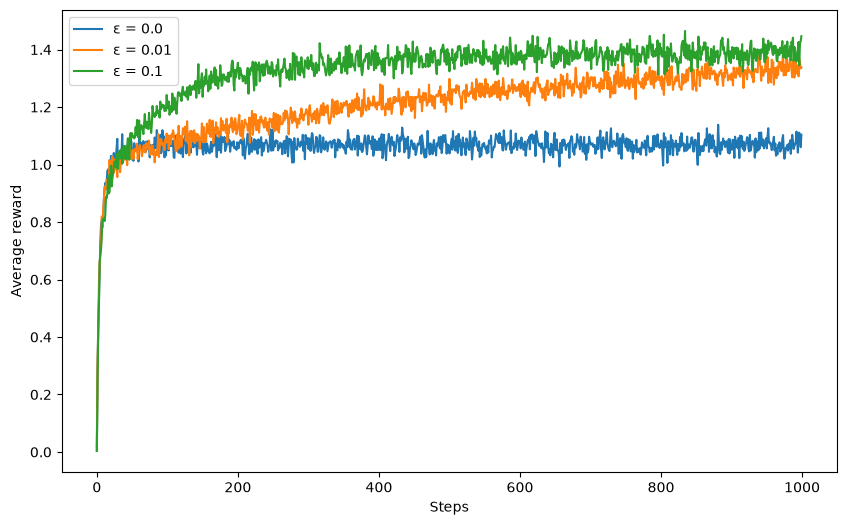

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for epsilon, (avg_reward, _) in results.items():
    ax.plot(avg_reward, label=f"\u03b5 = {epsilon}")
ax.set_xlabel("Steps")
ax.set_ylabel("Average reward")
ax.legend()
plt.show()

## Results: % Optimal Action

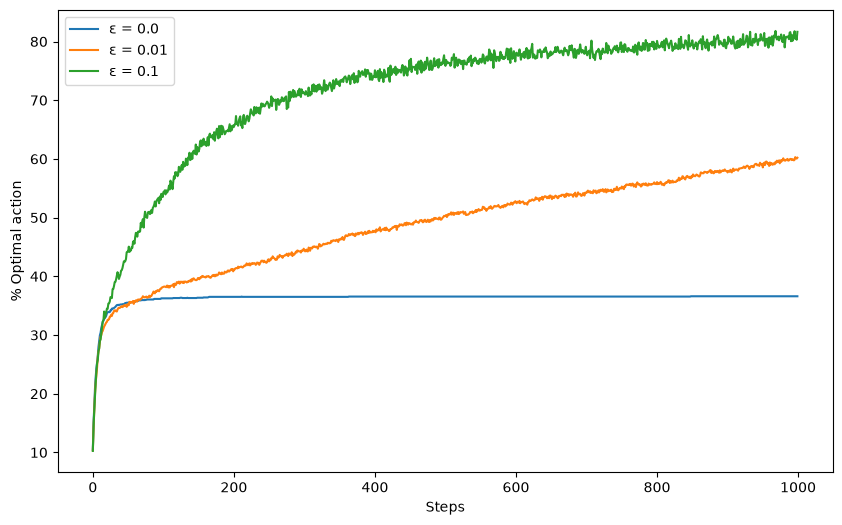

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for epsilon, (_, pct_optimal_action) in results.items():
    ax.plot(pct_optimal_action, label=f"\u03b5 = {epsilon}")
ax.set_xlabel("Steps")
ax.set_ylabel("% Optimal action")
ax.legend()
plt.show()